# R12 foundation - the interim identity pair set, H131 anisotropy removal, H130 string features

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R12 matching-model round, CPU-now batch <br>
**Graph**: rebuilt CPAP graph (neo4j2) <br>

Builds the interim labeled pair set every R12/R13 entry scores against, then adjudicates the
two zero-model hypotheses: H131 (the 0.93-0.99 cosine saturation is partly anisotropic GEOMETRY -
centering/whitening/component-removal over the stored Titan vectors spreads it) and H130 (on the
surface-variance class, classical string features match neural scoring).

Label honesty: positives are the H107 inventory (noisy - e.g. 'EN 60601-1-1' vs 'EN 60601-1' is
likely a true sibling mislabeled positive) plus same-name SAME_AS pairs (clean); negatives are
model-number siblings (generated), the 6 labeled false merges (clean), and random pairs (easy).
H101's adjudicated benchmark supersedes this set.

## Approach
1. **Pair set** - positives (noisy 66 + clean same-name SAME_AS), negatives (siblings + false merges + random)
2. **H131** - raw cosine baseline vs centered / PCA-whitened / all-but-top-k transforms: similarity spread + ranking AUC
3. **H130** - 4 string features + logistic (cross-validated), scored per class (variance vs sibling vs random)

## Outputs
- `reports/matching-r12-foundation-<stamp>.json` - pair set, AUC table, verdicts

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report + inventory
import glob  # latest inventory report
import os  # graph env
import re  # name handling
import random  # pair sampling

# third party
import numpy as np  # transforms
import Levenshtein  # string features
import matplotlib.pyplot as plt  # distributions
from pathlib import Path
from rich import print as rprint
from sklearn.linear_model import LogisticRegression  # H130
from sklearn.model_selection import cross_val_predict  # honest AUC
from sklearn.metrics import roc_auc_score

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"
from neo4j import GraphDatabase

random.seed(42)
np.random.seed(42)

In [2]:
# Configuration
ABTT_KS = [1, 3, 5, 10]      # all-but-the-top component removals to sweep
BAR_SPREAD = 3.0             # H131: pair-similarity IQR must spread >= 3x
BAR_AUC_GAIN = 0.05          # H131: duplicate-vs-sibling AUC gain
BAR_STRING_PARITY = 0.03     # H130: within this of the best neural score on variance class
N_RANDOM = 120               # easy negatives
N_SIBLINGS = 80              # hard negatives target

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Graph: [cyan]{os.environ['NEO4J_URI']}[/cyan]
  ABTT sweep: [yellow]{ABTT_KS}[/yellow]
  Bars: spread >= [yellow]{BAR_SPREAD}x[/yellow], AUC gain >= [yellow]{BAR_AUC_GAIN}[/yellow] (H131); parity [yellow]{BAR_STRING_PARITY}[/yellow] on variance (H130)
""")

Configuration
────────────────────────────────────────
  Graph: bolt://user-konrad.jelen-kgf-neo4j2:7687
  ABTT sweep: [1, 3, 5, 10]
  Bars: spread >= 3.0x, AUC gain >= 0.05 (H131); parity 0.03 on variance (H130)

## Pair set assembly

Positives: H107 inventory (66, noisy) + same-name SAME_AS (clean). Hard negatives: sibling
pairs generated from shared-family names with DIFFERING numeric model tokens. Clean negatives:
the 6 labeled false merges. Easy negatives: random pairs.

In [3]:
driver = GraphDatabase.driver(os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]),
    notifications_min_severity="OFF")
with driver.session() as s:
    ents = s.run("MATCH (e:Entity) WHERE e.embedding IS NOT NULL "
                 "RETURN e.id AS id, e.name AS name, labels(e) AS types, e.embedding AS emb").data()
    same_as = s.run("MATCH (a:Entity)-[r:SAME_AS]->(b:Entity) "
                    "RETURN a.id AS a, b.id AS b, r.method AS m").data()
driver.close()

E = {r["id"]: r for r in ents}
name_of = {r["id"]: r["name"] for r in ents}
by_id_emb = {r["id"]: np.array(r["emb"], dtype=np.float32) for r in ents}

inv = json.load(open(sorted(glob.glob("../reports/identity-forensics-r11-final-*.json"))[-1]))
name_to_id = {}
for r in ents:
    name_to_id.setdefault(r["name"], r["id"])

squash = lambda n: re.sub(r"[^a-z0-9]", "", (n or "").casefold())

pairs = []  # (id_a, id_b, label 1=same, cls)
for p in inv["pairs"]:
    a, b = name_to_id.get(p["a"]), name_to_id.get(p["b"])
    if a and b:
        cls = "variance" if p["cause"] == "extraction_variance" else "resolver_miss"
        pairs.append((a, b, 1, cls))

for r in same_as:
    if r["a"] in E and r["b"] in E and squash(name_of[r["a"]]) == squash(name_of[r["b"]]):
        pairs.append((r["a"], r["b"], 1, "samename"))

for m in inv["labeled_false_merges"]:
    a, b = name_to_id.get(m["a"]), name_to_id.get(m["b"])
    if a and b:
        pairs.append((a, b, 0, "false_merge"))

# sibling generation: same alpha-family, different numeric token
def family(name):
    toks = re.findall(r"[a-z]+", (name or "").casefold())
    return " ".join(toks[:3])
def nums(name):
    return set(re.findall(r"\d+", name or ""))

fams = {}
for r in ents:
    if nums(r["name"]):
        fams.setdefault(family(r["name"]), []).append(r["id"])
sibs = []
for fam, group in fams.items():
    if len(fam) < 6 or len(group) < 2:
        continue
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            a, b = group[i], group[j]
            if nums(name_of[a]) != nums(name_of[b]):
                sibs.append((a, b, 0, "sibling"))
random.shuffle(sibs)
pairs.extend(sibs[:N_SIBLINGS])

all_ids = list(E)
existing = {frozenset((a, b)) for a, b, _, _ in pairs}
n_rand = 0
while n_rand < N_RANDOM:
    a, b = random.sample(all_ids, 2)
    if frozenset((a, b)) not in existing:
        pairs.append((a, b, 0, "random")); existing.add(frozenset((a, b))); n_rand += 1

from collections import Counter
rprint(f"pair set: [yellow]{len(pairs)}[/yellow]  {dict(Counter(c for _,_,_,c in pairs))}")

pair set: 252  {'variance': 47, 'resolver_miss': 19, 'samename': 20, 'false_merge': 6, 'sibling': 40, 'random': 
120}

## H131 - anisotropy removal over the stored vectors

Transforms fit on ALL 2798 entity vectors (not the pair set): mean-centering, PCA whitening,
all-but-the-top-k removal (center, then remove the k dominant principal components). Metrics:
the similarity spread on the pair set (IQR ratio vs raw) and the duplicate-vs-sibling ranking
AUC - the decision band that matters.

In [4]:
X = np.stack([by_id_emb[i] for i in E])
Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
mu = Xn.mean(0)
Xc = Xn - mu
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

def transform(kind, k=0):
    if kind == "raw":
        return lambda v: v / np.linalg.norm(v)
    if kind == "center":
        return lambda v: (v / np.linalg.norm(v)) - mu
    if kind == "whiten":
        W = Vt.T / S * np.sqrt(len(Xc))
        return lambda v: ((v / np.linalg.norm(v)) - mu) @ W
    if kind == "abtt":
        P = Vt[:k].T @ Vt[:k]
        return lambda v: ((v / np.linalg.norm(v)) - mu) - ((v / np.linalg.norm(v)) - mu) @ P
    raise ValueError(kind)

def cos(u, v):
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9))

configs = [("raw", 0), ("center", 0), ("whiten", 0)] + [("abtt", k) for k in ABTT_KS]
results = {}
dup_sib = [(a, b, y) for a, b, y, c in pairs if c in ("variance", "resolver_miss", "samename", "sibling", "false_merge")]
for kind, k in configs:
    f = transform(kind, k)
    sims_all = [cos(f(by_id_emb[a]), f(by_id_emb[b])) for a, b, _, _ in pairs]
    ys = [y for a, b, y in dup_sib]
    ss = [cos(f(by_id_emb[a]), f(by_id_emb[b])) for a, b, y in dup_sib]
    q1, q3 = np.percentile(sims_all, [25, 75])
    results[f"{kind}{k or ''}"] = {"iqr": float(q3 - q1), "auc_dup_vs_hard": float(roc_auc_score(ys, ss))}

raw_iqr = results["raw"]["iqr"]; raw_auc = results["raw"]["auc_dup_vs_hard"]
best_name = max(results, key=lambda n: results[n]["auc_dup_vs_hard"])
best = results[best_name]
spread_ratio = best["iqr"] / max(raw_iqr, 1e-9)
h131 = "CONFIRMED" if best["auc_dup_vs_hard"] - raw_auc >= BAR_AUC_GAIN and spread_ratio >= BAR_SPREAD else (
    "PARTIAL" if best["auc_dup_vs_hard"] - raw_auc >= BAR_AUC_GAIN or spread_ratio >= BAR_SPREAD else "REFUTED")

rprint(f"""[bold cyan]H131 anisotropy removal[/bold cyan] [dim](duplicate-vs-hard-negative AUC; spread on all pairs)[/dim]""")
for n, r in results.items():
    tag = " [cyan]<- best[/cyan]" if n == best_name else ""
    rprint(f"  {n:9s} IQR [yellow]{r['iqr']:.4f}[/yellow]  AUC [yellow]{r['auc_dup_vs_hard']:.3f}[/yellow]{tag}")
rprint(f"  spread ratio [yellow]{spread_ratio:.1f}x[/yellow] (bar {BAR_SPREAD}x)  AUC gain [yellow]{best['auc_dup_vs_hard']-raw_auc:+.3f}[/yellow] (bar +{BAR_AUC_GAIN})  -> [{'green' if h131=='CONFIRMED' else 'red'}]{h131}[/]")

H131 anisotropy removal (duplicate-vs-hard-negative AUC; spread on all pairs)

raw       IQR 0.7639  AUC 0.888

center    IQR 0.8784  AUC 0.892

whiten    IQR 0.5517  AUC 0.901 <- best

abtt1     IQR 0.8719  AUC 0.900

abtt3     IQR 0.8656  AUC 0.892

abtt5     IQR 0.8631  AUC 0.889

abtt10    IQR 0.8475  AUC 0.890

spread ratio 0.7x (bar 3.0x)  AUC gain +0.013 (bar +0.05)  -> REFUTED

## H130 - the classical stack on the variance class

Four features: token-subset containment, Jaro-Winkler, length-normalized Levenshtein, numeric
model-token equality. Logistic with 5-fold cross-validated scores. Scored on the SAME
duplicate-vs-hard-negative task, then per class.

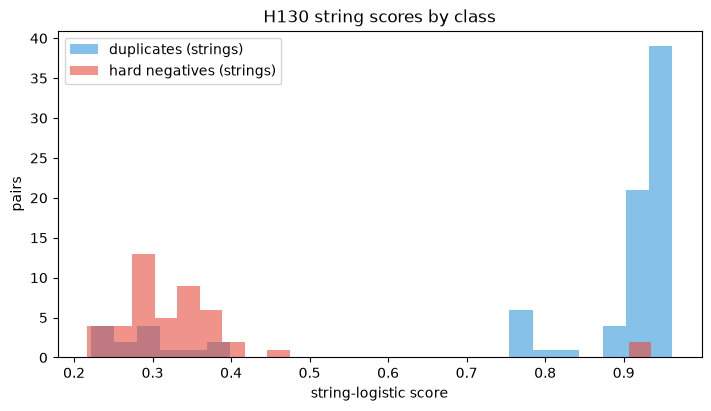

H130 strings vs best-transform embeddings
────────────────────────────────────────
  Overall (dup vs hard): strings 0.878  embeddings(whiten) 0.901  raw cosine 0.888
  Variance-vs-sibling:   strings 0.855  embeddings 0.947
  Interim H130: PENDING NEURAL (strings trail embeddings) (final vs the H121/H123 neural winners)

saved ../reports/matching-r12-foundation-20260706-211008.json

In [5]:
def string_feats(a, b):
    na, nb = name_of[a] or "", name_of[b] or ""
    ta, tb = set(re.findall(r"[a-z0-9]+", na.casefold())), set(re.findall(r"[a-z0-9]+", nb.casefold()))
    contain = len(ta & tb) / max(min(len(ta), len(tb)), 1)
    jw = Levenshtein.jaro_winkler(na.casefold(), nb.casefold())
    lev = 1 - Levenshtein.distance(na.casefold(), nb.casefold()) / max(len(na), len(nb), 1)
    num_eq = 1.0 if nums(na) == nums(nb) else 0.0
    return [contain, jw, lev, num_eq]

Xf = np.array([string_feats(a, b) for a, b, y in dup_sib])
yf = np.array([y for a, b, y in dup_sib])
clf = LogisticRegression(max_iter=1000)
scores = cross_val_predict(clf, Xf, yf, cv=5, method="predict_proba")[:, 1]
auc_strings = float(roc_auc_score(yf, scores))

# per-class: variance-positives vs sibling-negatives specifically
cls_map = [c for a, b, y, c in pairs if c in ("variance", "resolver_miss", "samename", "sibling", "false_merge")]
mask_var = [(c == "variance") or (c == "sibling") for c in cls_map]
auc_var_strings = float(roc_auc_score(yf[np.array(mask_var)], scores[np.array(mask_var)]))
f_best = transform(*(best_name.startswith("abtt") and ("abtt", int(best_name[4:])) or (best_name, 0)))
emb_scores = np.array([cos(f_best(by_id_emb[a]), f_best(by_id_emb[b])) for a, b, y in dup_sib])
auc_var_emb = float(roc_auc_score(yf[np.array(mask_var)], emb_scores[np.array(mask_var)]))
auc_emb_all = float(roc_auc_score(yf, emb_scores))

h130 = "CONFIRMED (interim)" if auc_var_strings >= auc_var_emb - BAR_STRING_PARITY else "PENDING NEURAL (strings trail embeddings)"

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for label, mask, color in [("duplicates", yf == 1, "#3498DB"), ("hard negatives", yf == 0, "#E74C3C")]:
    ax.hist(scores[mask], bins=25, alpha=0.6, label=f"{label} (strings)", color=color)
ax.set(xlabel="string-logistic score", ylabel="pairs", title="H130 string scores by class")
ax.legend()
plt.show()

rprint(f"""[bold cyan]H130 strings vs best-transform embeddings[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Overall (dup vs hard): strings [yellow]{auc_strings:.3f}[/yellow]  embeddings({best_name}) [yellow]{auc_emb_all:.3f}[/yellow]  raw cosine [yellow]{raw_auc:.3f}[/yellow]
  Variance-vs-sibling:   strings [yellow]{auc_var_strings:.3f}[/yellow]  embeddings [yellow]{auc_var_emb:.3f}[/yellow]
  Interim H130: [cyan]{h130}[/cyan] [dim](final vs the H121/H123 neural winners)[/dim]
""")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"matching-r12-foundation-{stamp}.json"
out.write_text(json.dumps({
    "pair_set": {"total": len(pairs), "classes": dict(Counter(c for _,_,_,c in pairs))},
    "h131": {"results": results, "best": best_name, "spread_ratio": spread_ratio,
              "auc_gain": best["auc_dup_vs_hard"] - raw_auc, "verdict": h131},
    "h130": {"auc_strings": auc_strings, "auc_var_strings": auc_var_strings,
              "auc_var_emb": auc_var_emb, "auc_emb_all": auc_emb_all, "interim": h130},
    "pairs": [{"a": name_of[a], "b": name_of[b], "y": y, "cls": c} for a, b, y, c in pairs],
}, indent=2, default=str))
rprint("saved", str(out))